In [ ]:
# ── CELL 1 : Installs & Imports ─────────────────────────────────────────────
!pip install -q tensorflow scikit-learn matplotlib seaborn

import os, json, pickle, random, urllib.request, tarfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Dense, Dropout, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TF version : 2.20.0
GPU        : []


In [ ]:
# ── CELL 2 : Mount Drive & Folders ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ICT4442_Project'

# Only folders for things we actually persist
DRIVE = {
    'root'    : BASE,
    'shared'  : f'{BASE}/shared',       # tokenizer lives here
    'mlp'     : f'{BASE}/MLP',
    'weights' : f'{BASE}/MLP/weights',
    'history' : f'{BASE}/MLP/history',
    'results' : f'{BASE}/MLP/results',
}
for d in DRIVE.values():
    os.makedirs(d, exist_ok=True)

# Local folders (Colab /content — ephemeral, no Drive space used)
LOCAL = {
    'data'   : '/content/data',
    'plots'  : '/content/plots/MLP',
}
for d in LOCAL.values():
    os.makedirs(d, exist_ok=True)

print("Drive folders (persisted):")
for k, v in DRIVE.items():
    print(f"  {k:10s} → {v}")
print("\nLocal folders (session only, no Drive space):")
for k, v in LOCAL.items():
    print(f"  {k:10s} → {v}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive folders (persisted):
  root       → /content/drive/MyDrive/ICT4442_Project
  shared     → /content/drive/MyDrive/ICT4442_Project/shared
  mlp        → /content/drive/MyDrive/ICT4442_Project/MLP
  weights    → /content/drive/MyDrive/ICT4442_Project/MLP/weights
  history    → /content/drive/MyDrive/ICT4442_Project/MLP/history
  results    → /content/drive/MyDrive/ICT4442_Project/MLP/results

Local folders (session only, no Drive space):
  data       → /content/data
  plots      → /content/plots/MLP


In [ ]:
# ── CELL 3 : Download IMDb Dataset to Local ──────────────────────────────────
DATA_PATH = '/content/data/aclImdb'

if not os.path.exists(DATA_PATH):
    print("Downloading IMDb dataset (~84 MB) to local /content ...")
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    urllib.request.urlretrieve(url, '/content/data/aclImdb_v1.tar.gz')
    print("Extracting...")
    with tarfile.open('/content/data/aclImdb_v1.tar.gz', 'r:gz') as t:
        t.extractall('/content/data/')
    os.remove('/content/data/aclImdb_v1.tar.gz')   # free local space
    print("Done.")
else:
    print("Dataset already in local — skipping download.")

def load_split(split_dir):
    texts, labels = [], []
    for label_idx, sentiment in enumerate(['neg', 'pos']):
        folder = os.path.join(split_dir, sentiment)
        for fname in sorted(os.listdir(folder)):
            if fname.endswith('.txt'):
                with open(os.path.join(folder, fname), encoding='utf-8') as f:
                    texts.append(f.read())
                labels.append(label_idx)
    return texts, labels

print("Loading splits...")
train_texts_full, train_labels_full = load_split(f'{DATA_PATH}/train')
test_texts,       test_labels       = load_split(f'{DATA_PATH}/test')

print(f"Train+Val : {len(train_texts_full)} reviews")
print(f"Test      : {len(test_texts)} reviews")
print(f"Balance   : {sum(train_labels_full)} pos / "
      f"{len(train_labels_full)-sum(train_labels_full)} neg")

Extracting...


/tmp/ipykernel_1837/1529179352.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('/content/data/')


Done.
Loading splits...
Train+Val : 25000 reviews
Test      : 25000 reviews
Balance   : 12500 pos / 12500 neg


In [ ]:
# ── CELL 4 : Train / Validation Split ───────────────────────────────────────
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full,
    test_size=5000, random_state=SEED, stratify=train_labels_full
)

train_labels = np.array(train_labels)
val_labels   = np.array(val_labels)
test_labels  = np.array(test_labels)

print(f"Train : {len(train_texts):>6,}  |  "
      f"Val : {len(val_texts):>5,}  |  "
      f"Test : {len(test_texts):>6,}")

Train : 20,000  |  Val : 5,000  |  Test : 25,000


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
# ── CELL 5 : Tokenise & Pad ──────────────────────────────────────────────────
VOCAB_SIZE = 20000
MAX_LEN    = 512
OOV_TOKEN  = '<OOV>'

TOKENIZER_PATH = f"{DRIVE['shared']}/tokenizer.pkl"

# Check if tokenizer already saved from a previous session
if os.path.exists(TOKENIZER_PATH):
    print("Loading existing tokenizer from Drive...")
    with open(TOKENIZER_PATH, 'rb') as f:
        tokenizer = pickle.load(f)
else:
    print("Fitting new tokenizer on training data...")
    tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
    tokenizer.fit_on_texts(train_texts)
    with open(TOKENIZER_PATH, 'wb') as f:
        pickle.dump(tokenizer, f)
    print(f"Tokenizer saved to Drive ({TOKENIZER_PATH})")

# Build sequences and pad — fast, done locally, not saved to Drive
train_seq = tokenizer.texts_to_sequences(train_texts)
val_seq   = tokenizer.texts_to_sequences(val_texts)
test_seq  = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print("Arrays built locally — NOT saved to Drive (rebuilt in seconds each session)")

Loading existing tokenizer from Drive...
X_train : (20000, 512)
X_val   : (5000, 512)
X_test  : (25000, 512)
Arrays built locally — NOT saved to Drive (rebuilt in seconds each session)


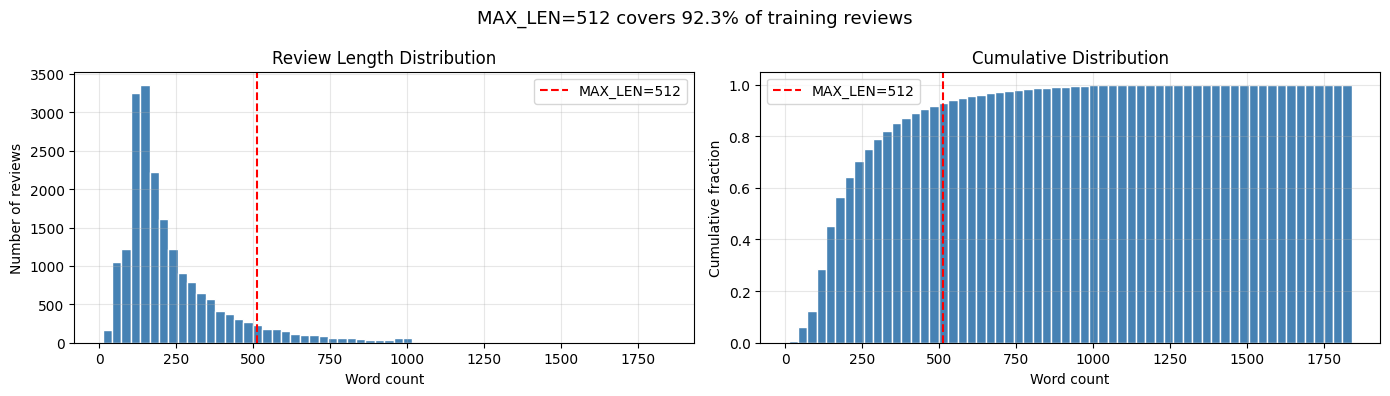

MAX_LEN=512 covers 92.3% of reviews.


In [ ]:
# ── CELL 6 : Review Length Distribution ─────────────────────────────────────
lengths = [len(s.split()) for s in train_texts]
pct     = np.mean(np.array(lengths) <= MAX_LEN) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(lengths, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[0].set_title('Review Length Distribution')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of reviews')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(lengths, bins=60, color='steelblue', edgecolor='white',
             cumulative=True, density=True)
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Cumulative Distribution')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Cumulative fraction')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f'MAX_LEN={MAX_LEN} covers {pct:.1f}% of training reviews', fontsize=13)
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/00_length_dist.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"MAX_LEN={MAX_LEN} covers {pct:.1f}% of reviews.")

In [ ]:
# ── CELL 7 : Build MLP ───────────────────────────────────────────────

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

EMBED_DIM = 128

def build_mlp():

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBED_DIM,
            name='embedding'
        ),

        # Regularization for the embedding representation
        SpatialDropout1D(
            0.2,
            name='embedding_dropout'
        ),

        GlobalAveragePooling1D(
            name='global_avg_pool'
        ),

        # Smaller baseline than the previous 128 -> 64 setup
        Dense(
            64,
            activation='relu',
            kernel_regularizer=l2(1e-4),
            name='dense_1'
        ),

        Dropout(
            0.4,
            name='dropout_1'
        ),

        Dense(
            1,
            activation='sigmoid',
            name='output'
        )

    ], name='MLP')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.build(input_shape=(None, MAX_LEN))

    return model


model = build_mlp()
model.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 512, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dropout               │ (None, 512, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,568,321 (9.80 MB)

 Trainable params: 2,568,321 (9.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── CELL 8 : Train MLP ───────────────────────────────────────────────

CHECKPOINT = f"{DRIVE['weights']}/mlp_best.keras"

BATCH_SIZE = 64
MAX_EPOCHS = 20

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=CHECKPOINT,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train,
    train_labels,
    validation_data=(X_val, val_labels),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# Save history
history_data = {
    'model': 'MLP',
    'epochs_run': len(history.history['loss']),
    'train_loss': history.history['loss'],
    'val_loss': history.history['val_loss'],
    'train_accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy']
}

with open(f"{DRIVE['history']}/mlp_history.json", 'w') as f:
    json.dump(history_data, f, indent=2)

print(f"\nEpochs run    : {history_data['epochs_run']}")
print(f"Best val_loss : {min(history_data['val_loss']):.4f}")
print(f"Best val_acc  : {max(history_data['val_accuracy']):.4f}")
print("History saved to Drive.")

Epoch 1/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5291 - loss: 0.6953
Epoch 1: val_loss improved from None to 0.62573, saving model to /content/drive/MyDrive/ICT4442_Project/MLP/weights/mlp_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ICT4442_Project/MLP/weights/mlp_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 81ms/step - accuracy: 0.5727 - loss: 0.6772 - val_accuracy: 0.6140 - val_loss: 0.6257 - learning_rate: 0.0010
Epoch 2/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7393 - loss: 0.5404
Epoch 2: val_loss improved from 0.62573 to 0.38034, saving model to /content/drive/MyDrive/ICT4442_Project/MLP/weights/mlp_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ICT4442_Project/MLP/weights/mlp_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.7751 - loss: 0.4843 - val_accuracy: 0.8526 - val_loss: 0.3803 - learning_rate: 0.0010
Epoch 3/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8378 -

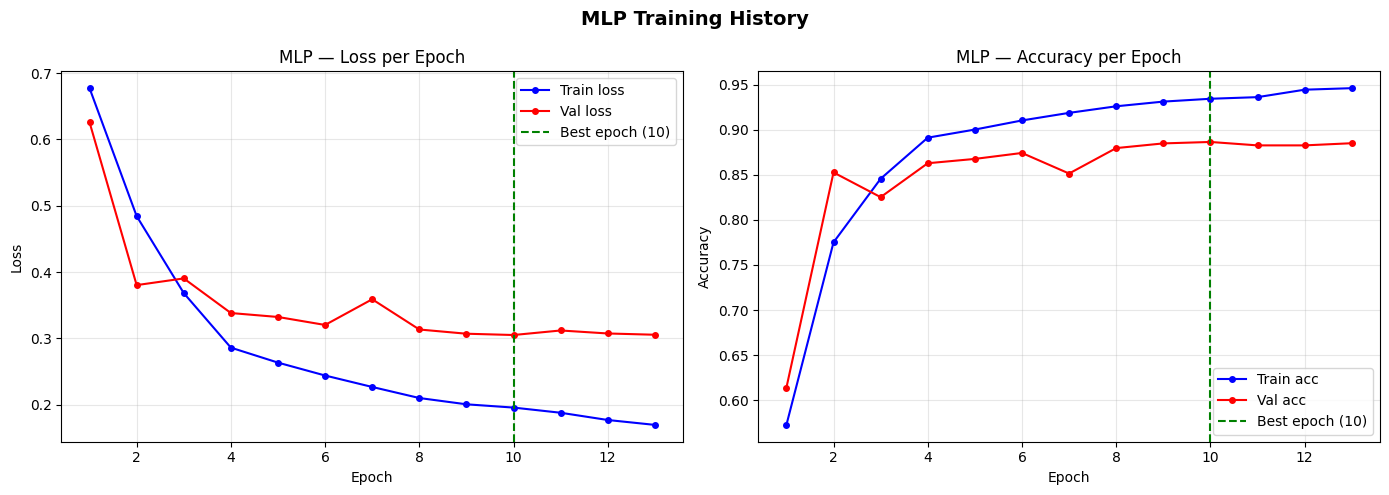

Best epoch: 10  |  val_loss=0.3051  |  val_acc=0.8864


In [ ]:
# ── CELL 9 : Training Curves ─────────────────────────────────────────────────
# Can re-run anytime by loading history from Drive:
# with open(f"{DRIVE['history']}/mlp_history.json") as f:
#     history_data = json.load(f)

epochs = range(1, history_data['epochs_run'] + 1)
best_e = np.argmin(history_data['val_loss']) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history_data['train_loss'],     'b-o', markersize=4, label='Train loss')
axes[0].plot(epochs, history_data['val_loss'],       'r-o', markersize=4, label='Val loss')
axes[0].axvline(best_e, color='green', linestyle='--', label=f'Best epoch ({best_e})')
axes[0].set_title('MLP — Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_data['train_accuracy'], 'b-o', markersize=4, label='Train acc')
axes[1].plot(epochs, history_data['val_accuracy'],   'r-o', markersize=4, label='Val acc')
axes[1].axvline(best_e, color='green', linestyle='--', label=f'Best epoch ({best_e})')
axes[1].set_title('MLP — Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('MLP Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/01_mlp_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Best epoch: {best_e}  |  "
      f"val_loss={history_data['val_loss'][best_e-1]:.4f}  |  "
      f"val_acc={history_data['val_accuracy'][best_e-1]:.4f}")

In [ ]:
# ── CELL 10 : Validation Evaluation ──────────────────────────────────────────
val_probs = model.predict(X_val, batch_size=64, verbose=0).flatten()
val_preds = (val_probs >= 0.5).astype(int)

val_metrics = {
    'split'    : 'validation',
    'accuracy' : float(accuracy_score(val_labels,  val_preds)),
    'precision': float(precision_score(val_labels, val_preds)),
    'recall'   : float(recall_score(val_labels,    val_preds)),
    'f1'       : float(f1_score(val_labels,        val_preds)),
    'auc'      : float(roc_auc_score(val_labels,   val_probs)),
}

print("── Validation Metrics ──────────────────────")
for k, v in val_metrics.items():
    if k != 'split':
        print(f"  {k:12s}: {v:.4f}")
print()
print(classification_report(val_labels, val_preds,
                             target_names=['Negative', 'Positive']))

# Save probs to Drive — small file, needed for final comparison notebook
np.save(f"{DRIVE['results']}/val_probs.npy", val_probs)
np.save(f"{DRIVE['results']}/val_preds.npy", val_preds)

fpr, tpr, _ = roc_curve(val_labels, val_probs)
roc_val = {'fpr': fpr.tolist(), 'tpr': tpr.tolist(),
           'auc': val_metrics['auc']}

with open(f"{DRIVE['results']}/val_metrics.json", 'w') as f:
    json.dump(val_metrics, f, indent=2)
with open(f"{DRIVE['results']}/roc_val.json", 'w') as f:
    json.dump(roc_val, f)

print("Val probs, preds, metrics, ROC saved to Drive.")

── Validation Metrics ──────────────────────
  accuracy    : 0.8864
  precision   : 0.8936
  recall      : 0.8772
  f1          : 0.8853
  auc         : 0.9501

              precision    recall  f1-score   support

    Negative       0.88      0.90      0.89      2500
    Positive       0.89      0.88      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000

Val probs, preds, metrics, ROC saved to Drive.


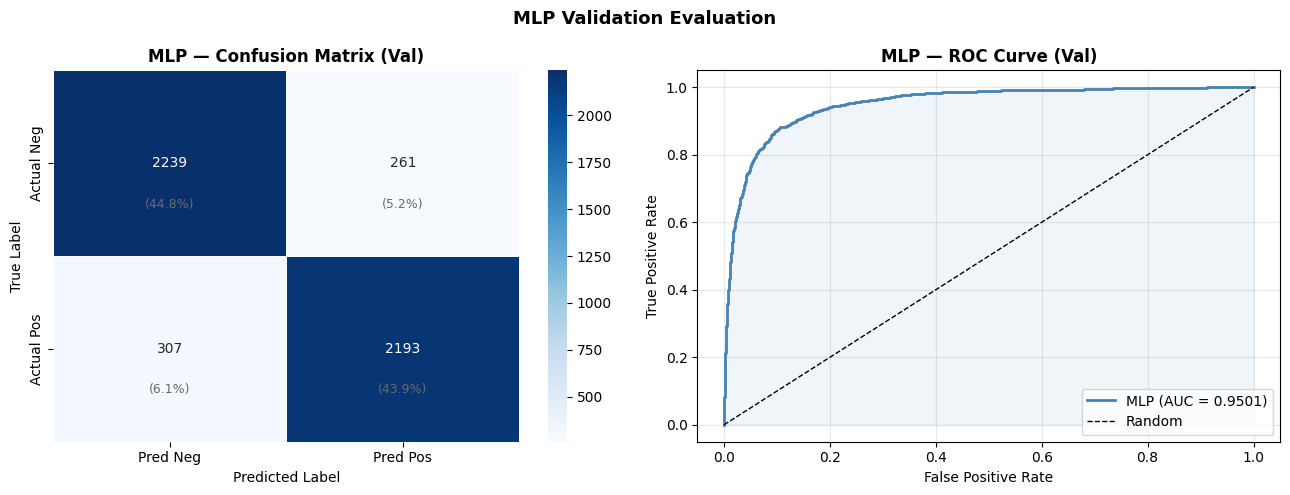

In [ ]:
# ── CELL 11 : Confusion Matrix + ROC — Validation ───────────────────────────
# To re-run without retraining:
# val_probs = np.load(f"{DRIVE['results']}/val_probs.npy")
# val_preds = np.load(f"{DRIVE['results']}/val_preds.npy")
# with open(f"{DRIVE['results']}/roc_val.json") as f: roc_val = json.load(f)

cm = confusion_matrix(val_labels, val_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'],
            linewidths=0.5)
for i in range(2):
    for j in range(2):
        axes[0].text(j+0.5, i+0.72,
                     f"({cm[i,j]/cm.sum()*100:.1f}%)",
                     ha='center', va='center',
                     fontsize=9, color='dimgray')
axes[0].set_title('MLP — Confusion Matrix (Val)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC
axes[1].plot(roc_val['fpr'], roc_val['tpr'],
             color='steelblue', lw=2,
             label=f"MLP (AUC = {roc_val['auc']:.4f})")
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[1].fill_between(roc_val['fpr'], roc_val['tpr'], alpha=0.08, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('MLP — ROC Curve (Val)', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.suptitle('MLP Validation Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/02_mlp_val_cm_roc.png", dpi=150, bbox_inches='tight')
plt.show()

── TEST RESULTS ───────────────────────────
  accuracy    : 0.8827
  precision   : 0.9011
  recall      : 0.8598
  f1          : 0.8799
  auc         : 0.9495

              precision    recall  f1-score   support

    Negative       0.87      0.91      0.89     12500
    Positive       0.90      0.86      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



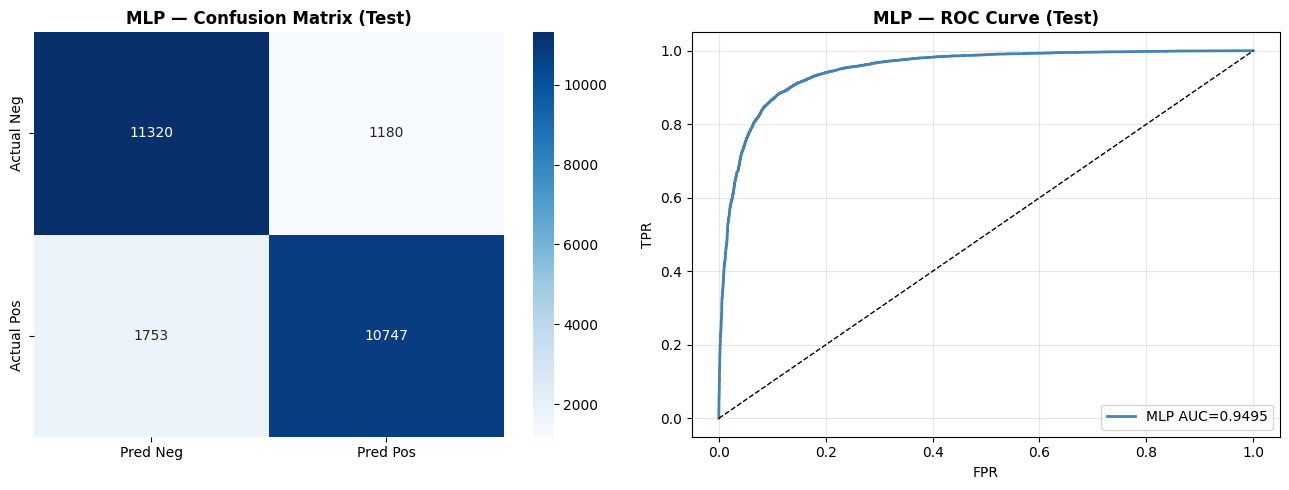

All test results saved to Drive.


In [ ]:
# ── CELL 12 : TEST SET EVALUATION ────────────────────────────────────────────
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ONLY RUN THIS AFTER ALL FOUR MODELS ARE FULLY FINALIZED.       ║
# ║  Running this during development contaminates your evaluation.  ║
# ╚══════════════════════════════════════════════════════════════════╝

test_probs = model.predict(X_test, batch_size=64, verbose=0).flatten()
test_preds = (test_probs >= 0.5).astype(int)

test_metrics = {
    'split'    : 'test',
    'accuracy' : float(accuracy_score(test_labels,  test_preds)),
    'precision': float(precision_score(test_labels, test_preds)),
    'recall'   : float(recall_score(test_labels,    test_preds)),
    'f1'       : float(f1_score(test_labels,        test_preds)),
    'auc'      : float(roc_auc_score(test_labels,   test_probs)),
}

print("── TEST RESULTS ───────────────────────────")
for k, v in test_metrics.items():
    if k != 'split':
        print(f"  {k:12s}: {v:.4f}")
print()
print(classification_report(test_labels, test_preds,
                             target_names=['Negative', 'Positive']))

fpr_t, tpr_t, _ = roc_curve(test_labels, test_probs)
roc_test = {'fpr': fpr_t.tolist(), 'tpr': tpr_t.tolist(),
            'auc': test_metrics['auc']}

np.save(f"{DRIVE['results']}/test_probs.npy", test_probs)
np.save(f"{DRIVE['results']}/test_preds.npy", test_preds)
with open(f"{DRIVE['results']}/test_metrics.json", 'w') as f:
    json.dump(test_metrics, f, indent=2)
with open(f"{DRIVE['results']}/roc_test.json", 'w') as f:
    json.dump(roc_test, f)

# Test confusion matrix + ROC
cm_t = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Neg','Pred Pos'],
            yticklabels=['Actual Neg','Actual Pos'])
axes[0].set_title('MLP — Confusion Matrix (Test)', fontweight='bold')
axes[1].plot(fpr_t, tpr_t, color='steelblue', lw=2,
             label=f"MLP AUC={test_metrics['auc']:.4f}")
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('MLP — ROC Curve (Test)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/03_mlp_test_cm_roc.png", dpi=150, bbox_inches='tight')
plt.show()
print("All test results saved to Drive.")